# **Classification problems**

Up to now, we have experienced how to deal with **regressions**: given a set $\{(x_j, y_j)\}_j$ of inputs $x_j$ and images $y_j$, the purpose was to interpolate a function $f_\theta(x)$ able to fit the correct curve.

Nevertheless, there exist many other classes of problems which require to parametrize a model function $f_\theta$ for predictions. In Supervised Learning, a practical example is provided by data **classification**: given a certain dataset, the model $f_\theta$ should be trained to divide the data into subsets of categories (or labels) $y_j$.

For this class of problems, the model should be able to extract some paramount features $\textbf{x}_j$ from the single data, and thereafter address it into a specific label $y_j$.

**Example: hand-written digits recognition**

- $\textbf{x}_j\in\mathbb{R}^n$: features addressed to the brightness of the $n$ pixels in the grid of the $j$-th image

- $y_j\in\mathbb{R}$: the label addressing the digits $\{0,1,\dots,9\}$

**Question: What values we can assign to the output of the Neural Network?**

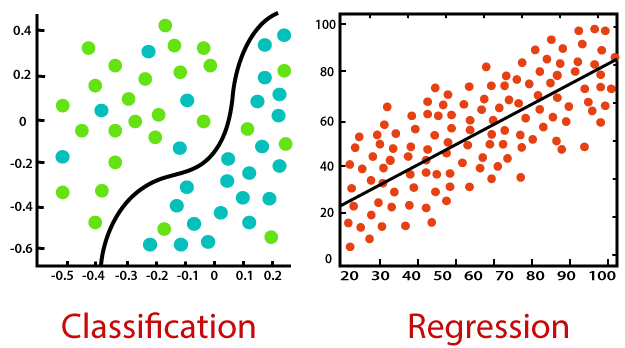

## Choosing the proper loss function and activation function for classification tasks

### Mean Average Error loss function



Up to now, we have introduced the Mean Squared Error (MSE) function for evaluating the loss during the training of the Neural Network. In order to perform a classification task, it is possible to introduce new loss functions. There exist a wide range of possible contestants, depending on which algorithm has to be applied for.

MSE is commonly used for regression problems, where the fitted function $f_\theta$ function enquires the correlations between the input variables $x_j$ and the outputs $y_j$, in order to predict results starting from the aknowledged data. Other loss functions fitting regression methods are Mean Average Error (MAE), where instead of squared discrepancy we take the absolute value:

\begin{equation}
  MAE\big(\{x_j, y_j\}_{j=1}^N\big) = \frac{1}{N}\sum_{i=1}^N \big| f_\theta(x_i) - y_i \big|
\end{equation}

Such loss softens the penalty for high values of discrepancy between $f$ and the $y_i$, which may turn to a lower overfitting on the data.

#### Multiclass classification

Another class of algorithms is provided by classification problems. In such case, instead of extending value predictions from a limited set of data, we want to fit a function which can predict the label we want to give to a certain feature $\{\textbf{x}_j\}_j$, a practical example is given by the pattern recognition problem.

For such algorithms, a good loss function is provided by the Cross-Entropy Loss ($CE$):

\begin{equation}
  CE\big(\{\textbf{x}_j, y_j\}_{j=1}^N\big) = -\sum_{j=1}^N y_j
  \ln\big[f_\theta(\textbf{x}_j)\big]
\end{equation}

This function gives you the information about the "distance" between the two probability distributions $\{y_j\}_j$ and $\{f_\theta(\textbf{x}_j)\}_j$.

### Why are we talking about distributions?

In classification problems, the Neural Network suitable to fit the function which solves such problems must give $m$ neurons in output, as the number of possible lables.

A probability is then linked to the value of these neurons, so the one with the greater probability gives the lable to the data feature.

So actually the fitted function is determined by

$$
\textbf{f}_\theta:\mathbb{R}^n\rightarrow\mathbb{R}^m
$$

where $n$ is the dimension of the data features, and $m$ is the number of lables.

To evaluate the Cross-Entropy loss function, the true lable linked to the features $\textbf{x}_j$ is always set to $y_j\rightarrow 1$, while $f_\theta(\textbf{x}_j)\leftarrow\textbf{f}_\theta(\textbf{x}_j)$ is the probability extracted from the neuron linked to the actual lable $y_j$.

In [ ]:
# Cross Entropy Loss

from torch import nn

nn.CrossEntropyLoss() # WARNING: it automatically apply a softmax on y

CrossEntropyLoss()

#### Binary classification

In case of binary classification, the output is bounded to lie in $\{0,1\}$, thus the cross entropy can be written as

\begin{equation}
  BCE\big(\{\textbf{x}_j, y_j\}_{j=1}^N\big) = - \sum_{j=1}^N\bigg[y_j\ln\big(f_\theta(\textbf{x}_j)\big) - (1-y_j)\ln\big(1-f_\theta(\textbf{x}_j)\big)\bigg]
\end{equation}

In [ ]:
# Binary classification loss

from torch import nn

nn.BCELoss()

BCELoss()

For further details, take a look at https://towardsdatascience.com/cross-entropy-loss-function-f38c4ec8643e

### Choosing the last layer activation function

#### Multiclass classification with softmax

While for regression we needed a range for $y_i$ equal to the codomain of the model to predict, for classification it is required a label in the $[0,1]$ range; furthermore, for binary classification two discrete variables $\{0,1\}$ suffice for the task. As the network output should be a probability normalized to 1, a **softmax activation** function could fit such purpose. However, **CrossEntropyLoss() applies the softmax automatically, so the last layer should be a linear activation function.**

Consider $\textbf{z}=[z_1, \dots, z_m]$ as the output layer of the Neural Network before the application of the softmax activation function $\sigma_{SM}$. The $k$-th output of the Neural Network is determined by:

$$
\textbf{f}_\theta(\textbf{x})_k= \sigma_{SM}(z_k) =
\frac{\exp[{z}_k]}{\sum_{j=1}^m \exp[z_j]}
$$

So we know each output is positive and then normalized.

#### Binary classification

As for binary classification, a **sigmoid** should work well: the output data, i.e. the probability to fall whether into $A$ or $B$ labels, should be approximated to the closest number to $0$ or $1$.

### Loss & Activation functions - Summary Table

Here follows a Summary Table for handling with activation and loss functions, with respect to the specific problem to tackle.

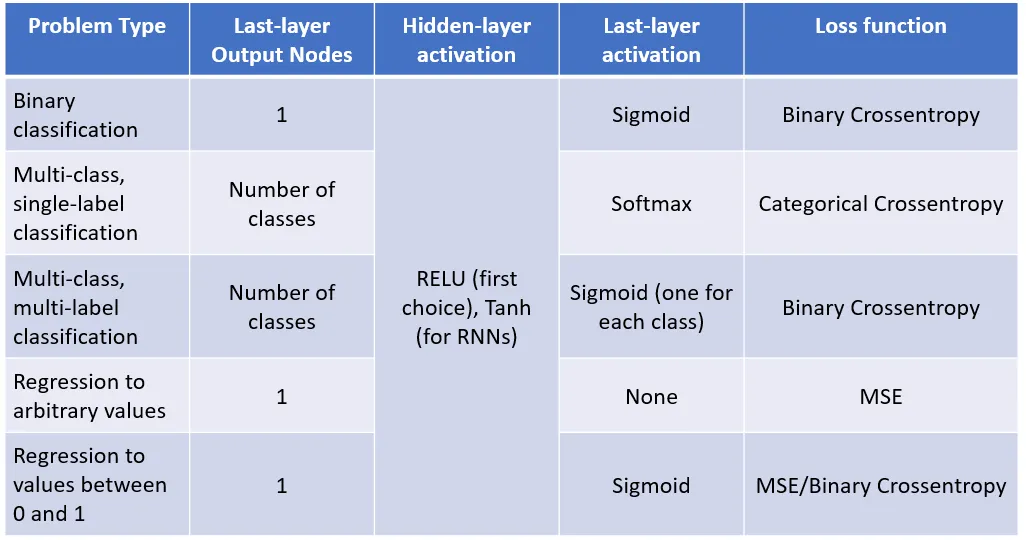

## Measuring the performance of a classification model: the accuracy

To test the correctness of our model, when predicting for classification, it is possible to introduce a new function, whose name is accuracy. The accuracy $A$ simply computes the percentage of correct guess from the model:

\begin{equation}
  A(n) = \frac{n_{correct}}{n_{total}}
\end{equation}

where $n$ is the total number of tests. Of course, if all the tests proved to be correct, $n_{correct}=n_{total}$ and $A(n)=1$.

For binary classification, it is possible to introduce another parameter, known as balanced accuracy. The balanced accuracy is defined as

\begin{equation}
  balanced \; accuracy = \frac{sensitivity + specificity}{2}
\end{equation}

where the sensitivity and specificity can be summed up as the probability to have a true positive or a true negative:

\begin{equation}
   sensitivity = \frac{TP}{TP + FN}
\end{equation}

\begin{equation}
  specificity = \frac{TN}{TN + FP}
\end{equation}

Such a classification can be summed up by the so-called confusion matrix:

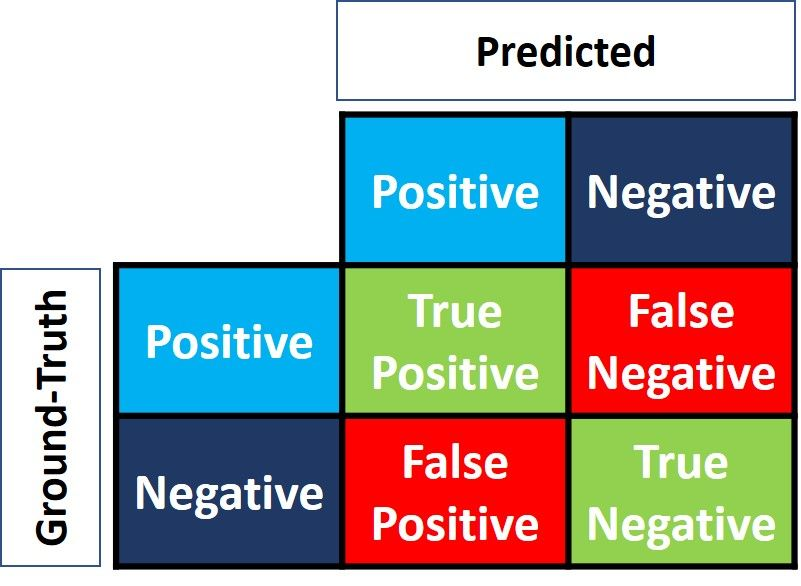

# Hands-on on binary classification - The Ising Model

The Ising model provides an interesting example of second order phase transitions, or continous phase transitions. Indeed, evolving with T the spin configurations smoothly vary from the ferromagnetic to the paramagnetic phase and vice versa. A scheme for such phase transition is provided in figure:


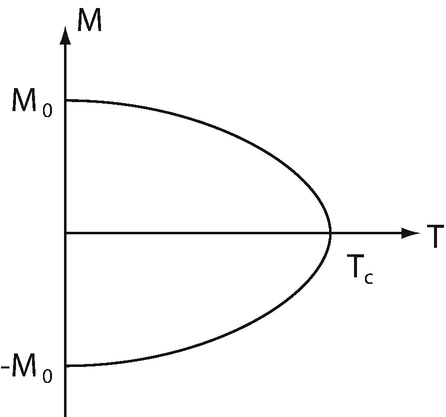

Increasing with the temperature, the magnetization (both positive or negative, depending on the spin alignment) gradually decrease to zero. At T=Tc (where Tc stands for the critic temperature) the averaged value for m is equal to zero. Therefore, there is no neat distinction between paramagnetic and ferromagnetic phase, as it happens for other phases of matter (the most notorious is the liquid-solid transition for H2O).


As an exercise of classification, it is possible to set a parameter $k=0.5$, so that if $|m|<k$ we will consider the Ising configuration to be paramagnetic, otherwise a ferromagnetic one.


**For a binary classification, the Binary Cross-Entropy loss function well fits our purpose.** Secondly, instead of a linear regression, we need to perform a different task: one additional layer, linked by Tanh and Sigmoid activation functions with the input and output layers, should work fine.

**Goal**: the purpose of this exercize is to convert the magnetization $m$ into a $\{0,1\}$ label to distinguish paramagnetic phase to the ferromagnetic one. Given a certain spin configuration $\{s \}_l$, the NN should be able to assign a correct label (meaning the paramagnetic or the ferromagnetic phase).

**Steps**


1.   Instantiate the FeedForward class template, this time with a new NN model architecture.
2.   Load the dataset and modify the labels, ranging in the $[-1,1]$ interval, into a binary set $\{0,1\}$. To perform such operation, it could be useful to insert the following command:
```
labels[np.abs(labels) > 0.5] = 1
labels[np.abs(labels) <= 0.5] = 0
```
With such option, all the $m$ values in the range $[-0.5;+0.5]$  will be addressed to be $0$, while in the other intervals they will be $0$. The variable label is now a list containing $0$ and $1$ instead of $m$.
3.   Split the dataset into a training and a testing batches
4.   Train the model
5.   Evaluate the model performances during the test on the sub-dataset by using the balanced accuracy





**Hints**



1.   Recycle the FeedForward class template from the Ising regression, rearranging the NN architecture
2.   To implement the NN architecture, it would be useful to introduce a hidden layers. As activation functions, a Tanh and a sigmoid should turn to work fine.

3.   The number of inputs is given by the number of cells from the data, and the output is equal to 1 (the magnetization value).
4.   When performing a regression, the best choice for the loss function usually is the BCE loss:
```
nn.BCELoss()
```
5.   when training the data, it could be useful to deploy the following methods:

```
dataset_train = TensorDataset(data_for_training, labels_for_training)
loader_train = DataLoader(dataset_train, batch_size=size_we_want, shuffle=True)
```
With such a setting, it is possible to train the model without any concern about the batch size during the for loop:
```
for data in loader_train:
    input_data, label = data
    ## TRAINING ##
```
6.   remember to employ the [accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) and [balanced_accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html) methods from sklearn!


Eventually, as more layers, along with non-linear activation functions are involved, more training may be required. Such achievement can be obtained by slightly modifying the training module in the main function:

In [27]:
!pip install pytorchtools

In [31]:
## Import libraries ##
import numpy as np
import sys

import torch
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score

In [24]:
## Class Template ##
class FeedForwardNN(nn.Module):
    def __init__(self, input_size,nh, output_size):
        super().__init__()

        # TODO:  DEFINE HERE THE LAYERS
        self.model = nn.Sequential(nn.Linear(input_size, nh),
                                    nn.Tanh(),
                                    nn.Linear(nh,output_size),
                                    nn.Sigmoid())
        # TODO: DEFINE HERE THE OPTIMIZER
        self.optimizer = torch.optim.Adam(self.model.parameters(),lr=0.01)
        # TODO: DEFINE HERE THE LOSS
        self.criterion = nn.BCELoss()
    def forward(self, x):
        output = self.model(x)
        return output

    def train_step(self, inputs, labels):
        """

        :param inputs:
        :param labels:
        :return:
        """

        # zero the parameter gradients
        self.optimizer.zero_grad()

        # forward + backward + optimize
        outputs = self.model(inputs)
        labels = labels.unsqueeze(1)
        loss = self.criterion(outputs, labels)
        loss.backward()
        self.optimizer.step()

        return loss.item()

In [42]:
def main():

    # Load the dataset
    path = '/home/timofey/AI for physics/ISING_1000step.npz'
    with np.load(path) as loader:
      raw_data = np.load("/home/timofey/AI for physics/ISING_1000step.npz")
    x_data, y_data = raw_data["grid"], raw_data["magnetizations"]
    

    # Convert to tensor
    labels = torch.tensor(y_data, dtype=torch.float32)
    data = torch.tensor(x_data, dtype=torch.float32)
    
    labels[labels > 0.5] = 1
    labels[labels <= 0.5] = 0

    # get the number of features (len_data, n_features)
    _, input_size = data.size()
    output_size = 1

    # We split the dataset into a training dataset and a test dataset. The former is used to train the model, while the
    # latter is used to evaluate the model performance
    # TODO: split the data into a training and a testing datasets (use "train_test_split" from sklearn.model_selection)
    # For further info: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
    data_train, data_test, labels_train, labels_test = train_test_split(data, labels, test_size = 0.2, stratify = labels, random_state=42)
    # Create dataset from several tensors with matching first dimension
    # Samples will be drawn from the first dimension (rows)
    dataset_train = TensorDataset(data_train, labels_train)

    # Create a data loader from the dataset
    # Batch size and number of workers are specified at this step
    loader_train = DataLoader(dataset_train, batch_size=16, shuffle=True)

    # We define the NN model
    # TODO: initialize the NN model
    network = FeedForwardNN(input_size=input_size, nh = 20, output_size=output_size)
    n_epochs = 100
    # Train model
    # for epoch, data in enumerate(loader_train):
    #     input_data, label = data

    #     # TODO: train the model
    #     loss = network.train_step(input_data,label)
    #     print(f'epoch {epoch}\t Loss {loss}')
    best_loss = float('inf')
    no_improvment = 0
    min_delta = 1e-4
    patience = 5
    for epoch in range(n_epochs):
      epoch_loss = 0
      for data in loader_train:
          input_data, label = data
          loss = network.train_step(input_data, label)
          epoch_loss +=loss
      epoch_loss /=len(loader_train)
      print(f'epoch {epoch} \t Loss {epoch_loss}')
      if epoch_loss < best_loss-min_delta:
         best_loss = epoch_loss
         no_improvment =0
      else:
         no_improvment +=1
         if no_improvment>=patience:
            print(f'Early stopping at epoch {epoch} with loss {epoch_loss} and best_loss {best_loss}')
            break
    #TODO: test the performance of the model using the test dataset
    network.eval()
    with torch.no_grad():
       preds = network(data_test)
       preds_binary = (preds>=0.5).float()
       labels_test = labels_test.unsqueeze(1)
       loss_test = accuracy_score(preds_binary, labels_test)
       loss_test_balanced = balanced_accuracy_score(preds_binary, labels_test)
       print(f'Accuracy {loss_test}\t Balanced accuracy {loss_test_balanced}')

In [43]:
model = main()

epoch 0 	 Loss 0.3230381253361702
epoch 1 	 Loss 0.08717414155602456
epoch 2 	 Loss 0.07166951158083976
epoch 3 	 Loss 0.04494778859661892
epoch 4 	 Loss 0.033432917265454304
epoch 5 	 Loss 0.029877574393176475
epoch 6 	 Loss 0.0298913526564138
epoch 7 	 Loss 0.031789632670115676
epoch 8 	 Loss 0.03615504255751148
epoch 9 	 Loss 0.02374063530791318
epoch 10 	 Loss 0.015198512423376087
epoch 11 	 Loss 0.011409768585508573
epoch 12 	 Loss 0.009435468661722552
epoch 13 	 Loss 0.0072573619362083265
epoch 14 	 Loss 0.006326478443625092
epoch 15 	 Loss 0.0050505567500658795
epoch 16 	 Loss 0.004656402116415848
epoch 17 	 Loss 0.004333347358133324
epoch 18 	 Loss 0.0038733358756689994
epoch 19 	 Loss 0.0034324294975704105
epoch 20 	 Loss 0.002719202169887467
epoch 21 	 Loss 0.002332642591400145
epoch 22 	 Loss 0.0020380975798912006
epoch 23 	 Loss 0.0018218986452757234
epoch 24 	 Loss 0.00181533605596087
epoch 25 	 Loss 0.0014766415279518696
epoch 26 	 Loss 0.0013664030028598972
epoch 27 	 Lo

In [ ]:
# Train model
for epoch in range(n_epochs):
    for data in loader_train:
        input_data, label = data
        loss = network.train_step(input_data, label)
        print("epoch: {}, loss: {}".format(epoch, loss))

with n_epochs to be specified as a parameter of the simulation. You may find the full code in the colab files.

# Facultative hands-on on multiclass classification - The Boson Higgs Challenge

The Boson Higgs Machine Learning Challenge was an open data analysis competition that took place between May and September 2014. Samples of simulated data from the ATLAS Experiment at the LHC corresponding to **signal events with Higgs bosons decaying to τ+τ– together with background events**.

The goal of the challenge was to develop any algorithm to separates signal to background noise. Competitors could use or develop any algorithm they want, and the one who achieves the best signal/background separation wins! Besides classical prizes for the winners, a special "HEP meets ML" prize will was also be awarded with an invitation to CERN.

Event website: https://higgsml.ijclab.in2p3.fr/

Documentation: https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf

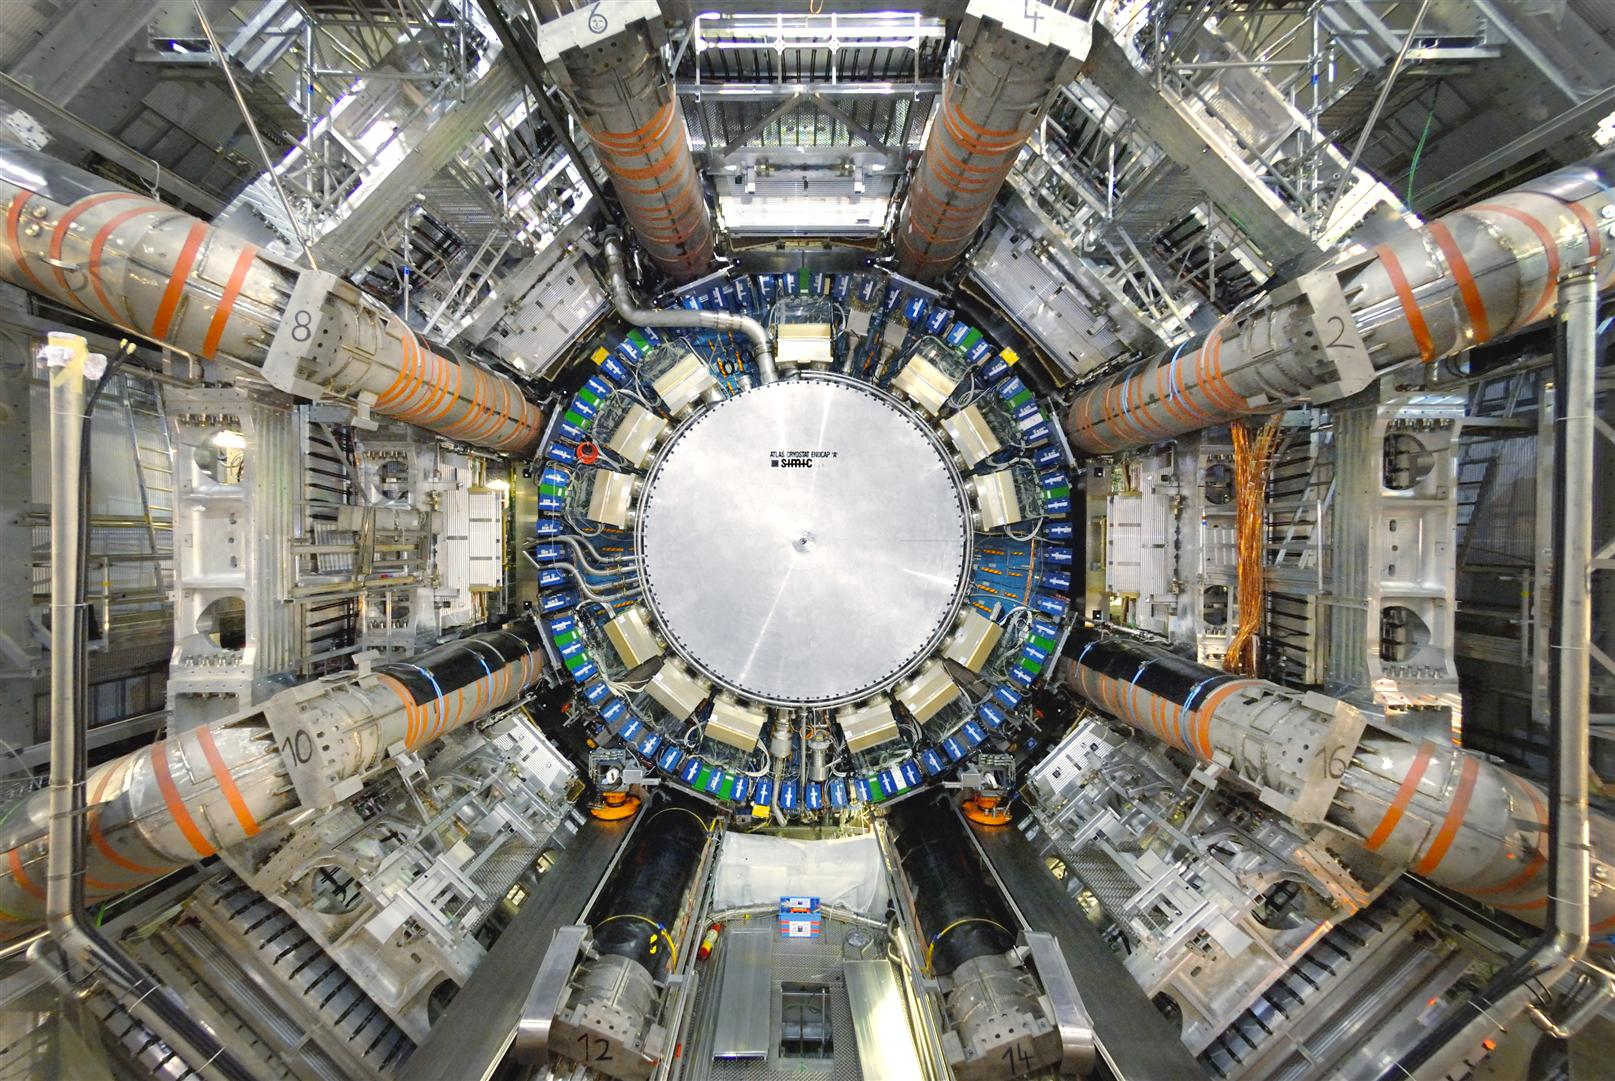

**The dataset:**

In a nutshell, the **data set contains a mixture of simulated signal and background events**, built from simulated events **provided by the ATLAS collaboration at CERN**. The simulated events that you will have in your hands are the same that physicists used.

*   It is a CSV file containing 250000 events.
*   The dataset is unbalanced
*   There are 21 features + 1 label (signal/noise)





**The goal:** your goal is to construct a neural network binary classifier to classify signals (Higgs decaying to leptons) from background noise.

**Steps**


1.   Instantiate the FeedForward class template, this time with a new NN model architecture.
2.   Load the csv dataset by using Pandas
```
raw_data = pd.read_csv("training_processed.csv")
```
3.   Split the dataset into a training and a testing batches
4.   Train the model
5.   Evaluate the model performances during the test on the testing dataset